In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestClassifier

In [58]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Forme :", df.shape)
df.head()

Forme : (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [59]:
def audit_qualite(df):
    print("Forme :", df.shape)
    print("\nTypes :")
    print(df.dtypes)
    print("\nPourcentage de valeurs manquantes :")
    print((df.isna().mean() * 100).sort_values(ascending=False))
    print("\nChurn en nombre :")
    print(df["Churn"].value_counts())
    print("\nChurn en pourcentage :")
    print(df["Churn"].value_counts(normalize=True) * 100)

In [60]:
audit_qualite(df)

Forme : (7043, 21)

Types :
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Pourcentage de valeurs manquantes :
customerID          0.0
DeviceProtection    0.0
TotalCharges        0.0
MonthlyCharges      0.0
PaymentMethod       0.0
PaperlessBilling    0.0
Contract            0.0
StreamingMovies     0.0
StreamingTV         0.0
TechSupport         0.0
OnlineBackup        0.0
gender              0.0
OnlineSecurity      0.0
InternetService     0

In [61]:
audit_qualite(df[df["Churn"] == "No"])

Forme : (5174, 21)

Types :
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Pourcentage de valeurs manquantes :
customerID          0.0
DeviceProtection    0.0
TotalCharges        0.0
MonthlyCharges      0.0
PaymentMethod       0.0
PaperlessBilling    0.0
Contract            0.0
StreamingMovies     0.0
StreamingTV         0.0
TechSupport         0.0
OnlineBackup        0.0
gender              0.0
OnlineSecurity      0.0
InternetService     0

# Phase 2 

In [62]:
def reparer_total_charges(df):
    df_repare = df.copy()
    total_numerique = pd.to_numeric(df_repare["TotalCharges"], errors="coerce")

    if total_numerique.notna().sum() == 0:
        raise ValueError("TotalCharges ne contient aucune valeur numérique.")

    valeurs_invalides = df_repare.loc[total_numerique.isna(), "TotalCharges"].unique()
    print("Valeurs illisibles trouvées :", valeurs_invalides)
    print("Trous révélés :", total_numerique.isna().sum())

    df_repare["TotalCharges"] = total_numerique.fillna(total_numerique.median())
    return df_repare

In [63]:
df_repare = reparer_total_charges(df)
print("Type après réparation :", df_repare["TotalCharges"].dtype)
print("Trous restants :", df_repare["TotalCharges"].isna().sum())

Valeurs illisibles trouvées : <StringArray>
[' ']
Length: 1, dtype: str
Trous révélés : 11
Type après réparation : float64
Trous restants : 0


In [64]:
df_texte = df.copy()
df_texte["TotalCharges"] = "texte"

try:
    reparer_total_charges(df_texte)
except ValueError as erreur:
    print("Erreur détectée :", erreur)

Erreur détectée : TotalCharges ne contient aucune valeur numérique.


In [65]:
df_virgule = df.head(3).copy()
df_virgule.loc[df_virgule.index[0], "TotalCharges"] = "29,90"
reparer_total_charges(df_virgule)

Valeurs illisibles trouvées : <StringArray>
['29,90']
Length: 1, dtype: str
Trous révélés : 1


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,998.825,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.500,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.150,Yes


# Phase 3 

In [66]:
def encoder_features(df):
    df_encode = df.copy()
    df_encode = df_encode.drop(columns="customerID")

    colonnes_texte = df_encode.select_dtypes(include=["object", "string"]).columns

    for colonne in colonnes_texte:
        if set(df_encode[colonne].dropna().unique()) <= {"Yes", "No"}:
            df_encode[colonne] = df_encode[colonne].map({"No": 0, "Yes": 1})

    df_encode = pd.get_dummies(df_encode, dtype=int)
    return df_encode

In [67]:
df_encode = encoder_features(df_repare)

print("Forme avant :", df_repare.shape)
print("Forme après :", df_encode.shape)
print("Colonnes texte restantes :", len(df_encode.select_dtypes(include=["object", "string"]).columns))

Forme avant : (7043, 21)
Forme après : (7043, 42)
Colonnes texte restantes : 0


In [68]:
print(df_repare["Contract"].unique())
print([colonne for colonne in df_encode.columns if colonne.startswith("Contract_")])

<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
['Contract_Month-to-month', 'Contract_One year', 'Contract_Two year']


In [69]:
df_rare = df_repare.copy()
df_rare["CategorieRare"] = "normale"
df_rare.loc[df_rare.index[0], "CategorieRare"] = "rare"
df_rare_encode = encoder_features(df_rare)

print("Clients dans CategorieRare_rare :", df_rare_encode["CategorieRare_rare"].sum())
print("Colonnes créées si customerID était encodé :", df_repare["customerID"].nunique())

Clients dans CategorieRare_rare : 1
Colonnes créées si customerID était encodé : 7043


# Phase 4 

In [70]:
def detecter_outliers_iqr(df, colonne):
    q1 = df[colonne].quantile(0.25)
    q3 = df[colonne].quantile(0.75)
    iqr = q3 - q1
    borne_basse = q1 - 1.5 * iqr
    borne_haute = q3 + 1.5 * iqr
    nombre_outliers = ((df[colonne] < borne_basse) | (df[colonne] > borne_haute)).sum()
    return borne_basse, borne_haute, nombre_outliers

In [71]:
colonnes_numeriques = ["tenure", "MonthlyCharges", "TotalCharges"]

for colonne in colonnes_numeriques:
    basse, haute, nombre = detecter_outliers_iqr(df_repare, colonne)
    print(f"{colonne} : {nombre} outlier(s), bornes [{basse:.2f}, {haute:.2f}]")

tenure : 0 outlier(s), bornes [-60.00, 124.00]
MonthlyCharges : 0 outlier(s), bornes [-46.02, 171.38]
TotalCharges : 0 outlier(s), bornes [-4674.34, 8863.16]


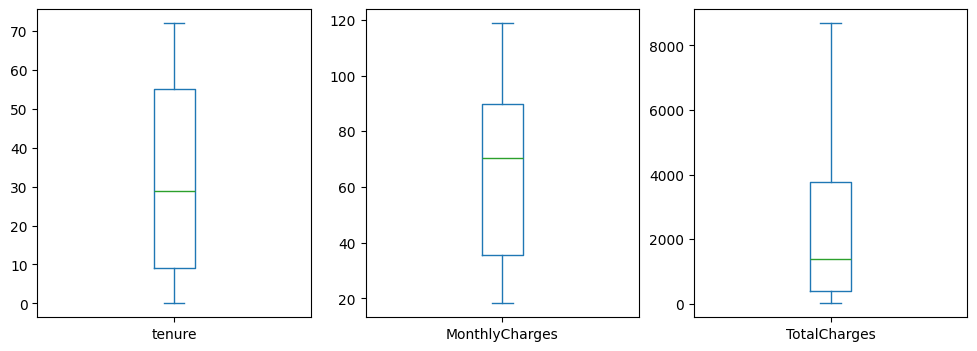

In [72]:
df_repare[colonnes_numeriques].plot(kind="box", subplots=True, figsize=(12, 4))
plt.show()

In [73]:
df_test_normal = pd.DataFrame({"valeur": [1, 2, 3, 4, 5]})
print("Test sans outlier :", detecter_outliers_iqr(df_test_normal, "valeur"))

Test sans outlier : (np.float64(-1.0), np.float64(7.0), np.int64(0))


In [74]:
basse, haute, nombre = detecter_outliers_iqr(df_repare, "TotalCharges")
masque_outliers = (df_repare["TotalCharges"] < basse) | (df_repare["TotalCharges"] > haute)
churn_perdus = (df_repare.loc[masque_outliers, "Churn"] == "Yes").sum()
total_churn = (df_repare["Churn"] == "Yes").sum()

print("Clients supprimés :", masque_outliers.sum())
print(f"Clients churn perdus : {churn_perdus} ({churn_perdus / total_churn * 100:.2f} %)")
print("Décision : garder les valeurs, car elles peuvent représenter de vrais clients.")

Clients supprimés : 0
Clients churn perdus : 0 (0.00 %)
Décision : garder les valeurs, car elles peuvent représenter de vrais clients.


# Phase 5 

In [75]:
def rapport_multicolinearite(df, colonnes_num):
    donnees = df[colonnes_num]

    sns.heatmap(donnees.corr(), annot=True, cmap="coolwarm")
    plt.show()

    vif = pd.DataFrame({
        "colonne": colonnes_num,
        "VIF": [variance_inflation_factor(donnees.values, i) for i in range(len(colonnes_num))]
    })
    print(vif)
    print("\nVIF supérieur à 5 :")
    print(vif[vif["VIF"] > 5])
    return vif

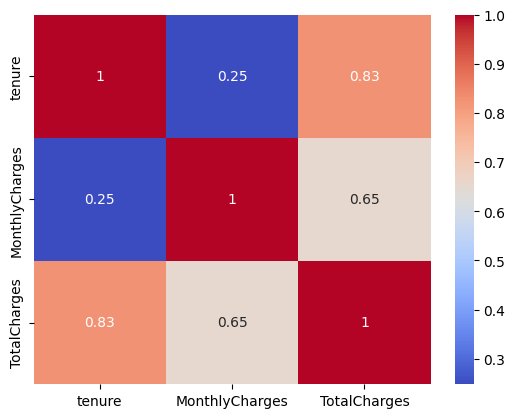

          colonne       VIF
0          tenure  6.321802
1  MonthlyCharges  3.360371
2    TotalCharges  8.073814

VIF supérieur à 5 :
        colonne       VIF
0        tenure  6.321802
2  TotalCharges  8.073814


In [76]:
vif_avant = rapport_multicolinearite(df_repare, colonnes_numeriques)

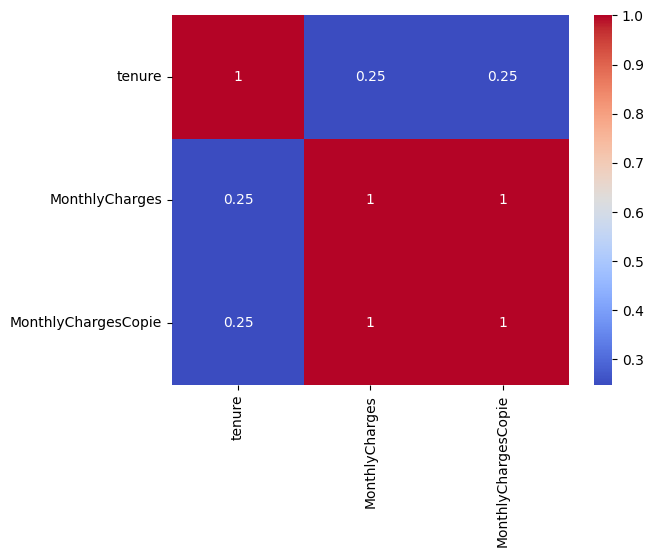

               colonne       VIF
0               tenure  2.612607
1       MonthlyCharges       inf
2  MonthlyChargesCopie       inf

VIF supérieur à 5 :
               colonne  VIF
1       MonthlyCharges  inf
2  MonthlyChargesCopie  inf


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [77]:
df_duplique = df_repare.copy()
df_duplique["MonthlyChargesCopie"] = df_duplique["MonthlyCharges"]
vif_duplique = rapport_multicolinearite(
    df_duplique,
    ["tenure", "MonthlyCharges", "MonthlyChargesCopie"]
)

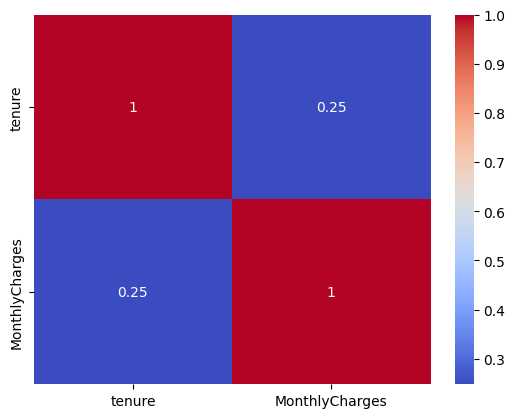

          colonne       VIF
0          tenure  2.612607
1  MonthlyCharges  2.612607

VIF supérieur à 5 :
Empty DataFrame
Columns: [colonne, VIF]
Index: []
Décision : retirer TotalCharges peut réduire la redondance, mais il faudra comparer les modèles avant/après.


In [78]:
vif_apres = rapport_multicolinearite(df_repare, ["tenure", "MonthlyCharges"])
print("Décision : retirer TotalCharges peut réduire la redondance, mais il faudra comparer les modèles avant/après.")

# Phase 6 

In [80]:
def features_discriminantes(df, cible="Churn"):
    X = df.drop(columns=cible)
    y = df[cible]

    correlation = X.corrwith(y).abs().sort_values(ascending=False)

    foret = RandomForestClassifier(n_estimators=100, random_state=42)
    foret.fit(X, y)
    importance = pd.Series(foret.feature_importances_, index=X.columns).sort_values(ascending=False)

    classement = pd.DataFrame({
        "Top corrélation": correlation.index[:10],
        "Corrélation": correlation.values[:10],
        "Top Random Forest": importance.index[:10],
        "Importance": importance.values[:10]
    })
    print(classement)
    return correlation, importance

In [81]:
correlations, importances = features_discriminantes(df_encode)

                   Top corrélation  Corrélation  \
0          Contract_Month-to-month     0.405103   
1                           tenure     0.352229   
2                OnlineSecurity_No     0.342637   
3                   TechSupport_No     0.337281   
4      InternetService_Fiber optic     0.308020   
5                Contract_Two year     0.302253   
6   PaymentMethod_Electronic check     0.301919   
7                  OnlineBackup_No     0.268005   
8              DeviceProtection_No     0.252481   
9  TechSupport_No internet service     0.227890   

                Top Random Forest  Importance  
0                    TotalCharges    0.169838  
1                          tenure    0.148793  
2                  MonthlyCharges    0.145419  
3         Contract_Month-to-month    0.055102  
4                  TechSupport_No    0.033966  
5               OnlineSecurity_No    0.030078  
6  PaymentMethod_Electronic check    0.027048  
7     InternetService_Fiber optic    0.025191  
8     

In [82]:
df_constante = df_encode.copy()
df_constante["colonne_constante"] = 1
correlations_constante, importances_constante = features_discriminantes(df_constante)

print("Importance de la colonne constante :", importances_constante["colonne_constante"])

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


                   Top corrélation  Corrélation  \
0          Contract_Month-to-month     0.405103   
1                           tenure     0.352229   
2                OnlineSecurity_No     0.342637   
3                   TechSupport_No     0.337281   
4      InternetService_Fiber optic     0.308020   
5                Contract_Two year     0.302253   
6   PaymentMethod_Electronic check     0.301919   
7                  OnlineBackup_No     0.268005   
8              DeviceProtection_No     0.252481   
9  TechSupport_No internet service     0.227890   

                Top Random Forest  Importance  
0                    TotalCharges    0.172481  
1                  MonthlyCharges    0.147089  
2                          tenure    0.142656  
3         Contract_Month-to-month    0.054342  
4               OnlineSecurity_No    0.032437  
5  PaymentMethod_Electronic check    0.027959  
6                  TechSupport_No    0.027100  
7                PaperlessBilling    0.024874  
8     